Name: Mahmoud Faisal,
IMDB , Metacritic Data Analysis

In [83]:
!pip install scikit-learn



1️⃣ Connect to MongoDB Atlas

Objective:
Securely connect Jupyter Notebook to MongoDB using credentials stored in a JSON file. This prevents exposing sensitive connection strings.

In [84]:
import json
from pymongo import MongoClient
import certifi
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import sys
from sklearn.preprocessing import StandardScaler

# Load credentials
with open('credentials.json') as f:
    creds = json.load(f)

client = MongoClient(
    creds["mongodb"],
    tls=True,
    tlsCAFile=certifi.where()
)

db = client["Imdb"]
print(db.list_collection_names())


['imdb2', 'Metacritic', 'IMDB_Pipeline_view']


🎬 2️⃣ Load IMDB Data and Filter Movies from Year 2000

Objective:
Retrieve IMDB data from MongoDB and filter movies released in the year 2000.

In [85]:
# Load IMDB collection
cursor = db["IMDB_Pipeline_view"].find()
imdb = pd.DataFrame(cursor)

# Show basic dataset structure
print("IMDB Dataset Shape:", imdb.shape)
print("\nIMDB Columns:")
print(imdb.columns)

print("\nFirst 5 rows of IMDB dataset:")
display(imdb.head())

# Convert release_date to datetime
imdb['release_date'] = pd.to_datetime(imdb['release_date'], errors='coerce')

# Filter year 2000
imdb = imdb[imdb['release_date'].dt.year == 2000]

print("\nIMDB Movies Released in 2000:", len(imdb))
display(imdb.head())

# Clean title for merging
imdb['title'] = (
    imdb['title']
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
)



IMDB Dataset Shape: (29825, 31)

IMDB Columns:
Index(['_id', 'budget', 'cast', 'certification', 'company', 'director',
       'genres', 'gross_sales', 'id', 'opening_weekend', 'producer',
       'release_date', 'runtime', 'title', 'user_rating', 'votes',
       'is_gross_sales_usd', 'gross_sales_value', 'gross_sales_new',
       'gross_sales_new2', 'is_budget_usd', 'budget_value', 'budget_new',
       'is_opening_weekend_usd', 'opening_weekend_value', 'opening_new',
       'certlist', 'matching_certification', 'release_date_fixed', 'year',
       'month'],
      dtype='object')

First 5 rows of IMDB dataset:


,_id,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,budget_value,budget_new,is_opening_weekend_usd,opening_weekend_value,opening_new,certlist,matching_certification,release_date_fixed,year,month
0,6366e140fcbf171967d878cf,None,"Walter Matthau, Glenda Jackson, Art Carney, Ri...",PG,Universal Pictures,Howard Zieff,"Comedy, Drama, Romance",None,77699,None,...,None,None,False,None,None,[PG],[],1978-03-15,1978,3
1,6366e15ffcbf171967d878dc,None,"Kuan Tai Chen, Feng Lu, Phillip Chung-Fung Kwo...",R,Shaw Brothers,Cheh Chang,"Action, Drama",None,77292,None,...,None,None,False,None,None,[R],[],1978-12-21,1978,12
2,6366e186fcbf171967d878ed,None,"Shashi Kapoor, Zeenat Aman, Kanhaiyalal Chatur...",NaN,R.K. Films Ltd.,Raj Kapoor,"Drama, Romance",None,78204,None,...,None,None,False,None,None,None,None,1978-03-22,1978,3
3,6366e1d6fcbf171967d8790d,"$4,700,000 (estimated)","James Brolin, Margot Kidder, Rod Steiger, Don ...",R,"American International Pictures, Cinema 77, Pr...",Stuart Rosenberg,Horror,None,78767,"$7,843,467, 29 Jul 1979",...,"{'match': '4,700,000', 'idx': 1, 'captures': [...",4700000,True,"{'match': '7,843,467,', 'idx': 1, 'captures': ...",7843467,[R],[],1979-07-27,1979,7
4,6366e2c8fcbf171967d87971,"$5,300,000 (estimated)","Barry Newman, Susan Clark, Shelley Winters, Le...",R,"Astral Bellevue Pathé, Astral Films, Canadian ...",Alvin Rakoff,"Action, Drama",None,78976,None,...,"{'match': '5,300,000', 'idx': 1, 'captures': [...",5300000,False,None,None,[R],[],1979-05-14,1979,5



IMDB Movies Released in 2000: 558


,_id,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,budget_value,budget_new,is_opening_weekend_usd,opening_weekend_value,opening_new,certlist,matching_certification,release_date_fixed,year,month
7001,636afd653bc31743d94b4a17,"$23,000,000 (estimated)","Richard Gere, Helen Hunt, Farrah Fawcett, Laur...",R,"Artisan Entertainment, Sandcastle 5 Productions",Robert Altman,"Comedy, Drama, Romance","$22,844,291, 18 Jan 2001",205271,"$5,012,867, 15 Oct 2000",...,"{'match': '23,000,000', 'idx': 1, 'captures': ...",23000000,True,"{'match': '5,012,867,', 'idx': 1, 'captures': ...",5012867,[R],[],2000-09-01,2000,9
7002,636afeb03bc31743d94b4aa0,None,"Paul Cook, Steve Jones, John Lydon, Glen Matlo...","TV-MA::(cable rating), R","FilmFour, Jersey Shore, Nitrate Films, Panacea...",Julien Temple,"Documentary, Biography, Music",None,236216,None,...,None,None,False,None,None,"[TV-MA::(cable rating), R]",[ R],2000-01-25,2000,1
7003,636b001c3bc31743d94b4afe,"$500,000 (estimated)","James Ronald Whitney, Melvin Just",NaN,Production 920,James Ronald Whitney,Documentary,None,240641,None,...,"{'match': '500,000', 'idx': 1, 'captures': ['5...",500000,False,None,None,None,None,2000-01-08,2000,1
7004,636afcfb3bc31743d94b49ec,"$4,000,000 (estimated)","Amitabh Bachchan, Shah Rukh Khan, Uday Chopra,...",Not Rated,Yash Raj Films,Aditya Chopra,"Musical, Drama, Romance",None,213890,None,...,"{'match': '4,000,000', 'idx': 1, 'captures': [...",4000000,False,None,None,[Not Rated],[],2000-10-27,2000,10
7005,636afc263bc31743d94b499a,"$80,000,000 (estimated)","Shawn Driscoll, Kevin Costner, Drake Cook, Luc...",PG-13,"New Line Cinema, Beacon Communications, Beacon...",Roger Donaldson,"Drama, History, Thriller","$66,579,890",146309,"$46,668, 29 Dec 2000",...,"{'match': '80,000,000', 'idx': 1, 'captures': ...",80000000,True,"{'match': '46,668,', 'idx': 1, 'captures': ['4...",46668,[PG-13],[],2000-12-16,2000,12


🎭 3️⃣ Load Metacritic Data and Filter Year 2000

Objective:
Retrieve Metacritic dataset and filter movies released in the same year for comparison.

In [86]:
# Load Metacritic collection
cursor2 = db["Metacritic"].find()
metacritic = pd.DataFrame(cursor2)

# Show dataset structure
print("Metacritic Dataset Shape:", metacritic.shape)
print("\nMetacritic Columns:")
print(metacritic.columns)

print("\nFirst 5 rows of Metacritic dataset:")
display(metacritic.head())

# Convert release_date
metacritic['release_date'] = pd.to_datetime(metacritic['release_date'], errors='coerce')

# Filter year 2000
metacritic = metacritic[metacritic['release_date'].dt.year == 2000]

print("\nMetacritic Movies Released in 2000:", len(metacritic))
display(metacritic.head())

# Clean title for merging
metacritic['title'] = (
    metacritic['title']
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
)


Metacritic Dataset Shape: (10828, 7)

Metacritic Columns:
Index(['_id', 'movie_id', 'title', 'release_date', 'description', 'score',
       'thumbnail'],
      dtype='object')

First 5 rows of Metacritic dataset:


,_id,movie_id,title,release_date,description,score,thumbnail
0,67364f526d467415bc2a2174,11257,High Fidelity,2000-03-31 08:00:00,"In this biting romantic comedy, Rob Gordon (Cu...",79,https://static.metacritic.com/images/products/...
1,67364f526d467415bc2a21b6,11323,The Cup,2000-01-28 08:00:00,World Cup fever has reached the Indian Himalay...,70,https://static.metacritic.com/images/products/...
2,67364f526d467415bc2a2167,11244,Paragraph 175,2000-09-13 07:00:00,"During World War II 100,000 German homosexual ...",85,https://static.metacritic.com/images/products/...
3,67364f526d467415bc2a2207,11404,Non-Stop,2000-11-10 08:00:00,The story of three losers brought together by ...,56,https://static.metacritic.com/images/products/...
4,67364f526d467415bc2a22f5,11642,Southern Comfort,2001-02-23 08:00:00,"Against the backdrop of rural Georgia, this do...",78,https://static.metacritic.com/images/products/...



Metacritic Movies Released in 2000: 364


,_id,movie_id,title,release_date,description,score,thumbnail
0,67364f526d467415bc2a2174,11257,High Fidelity,2000-03-31 08:00:00,"In this biting romantic comedy, Rob Gordon (Cu...",79,https://static.metacritic.com/images/products/...
1,67364f526d467415bc2a21b6,11323,The Cup,2000-01-28 08:00:00,World Cup fever has reached the Indian Himalay...,70,https://static.metacritic.com/images/products/...
2,67364f526d467415bc2a2167,11244,Paragraph 175,2000-09-13 07:00:00,"During World War II 100,000 German homosexual ...",85,https://static.metacritic.com/images/products/...
3,67364f526d467415bc2a2207,11404,Non-Stop,2000-11-10 08:00:00,The story of three losers brought together by ...,56,https://static.metacritic.com/images/products/...
6,67364f526d467415bc2a21d7,11356,Vénus beauté (institut),2000-10-27 07:00:00,This film takes us into this world of beauty a...,64,https://static.metacritic.com/images/products/...


🔗 4️⃣ Merge IMDB and Metacritic Datasets

Objective:
Combine both datasets using movie title as the key.

In [87]:
# Merge on cleaned title
unified_view = pd.merge(imdb, metacritic, how="inner", on="title")

print("Merged Dataset Shape:", unified_view.shape)

print("\nMerged Columns:")
print(unified_view.columns)

print("\nFirst 5 rows of merged dataset:")
display(unified_view.head())

print("\nSummary statistics of numeric columns:")
display(unified_view.describe())


Merged Dataset Shape: (193, 37)

Merged Columns:
Index(['_id_x', 'budget', 'cast', 'certification', 'company', 'director',
       'genres', 'gross_sales', 'id', 'opening_weekend', 'producer',
       'release_date_x', 'runtime', 'title', 'user_rating', 'votes',
       'is_gross_sales_usd', 'gross_sales_value', 'gross_sales_new',
       'gross_sales_new2', 'is_budget_usd', 'budget_value', 'budget_new',
       'is_opening_weekend_usd', 'opening_weekend_value', 'opening_new',
       'certlist', 'matching_certification', 'release_date_fixed', 'year',
       'month', '_id_y', 'movie_id', 'release_date_y', 'description', 'score',
       'thumbnail'],
      dtype='object')

First 5 rows of merged dataset:


,_id_x,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,matching_certification,release_date_fixed,year,month,_id_y,movie_id,release_date_y,description,score,thumbnail
0,636afeb03bc31743d94b4aa0,None,"Paul Cook, Steve Jones, John Lydon, Glen Matlo...","TV-MA::(cable rating), R","FilmFour, Jersey Shore, Nitrate Films, Panacea...",Julien Temple,"Documentary, Biography, Music",None,236216,None,...,[ R],2000-01-25,2000,1,67364f526d467415bc2a216b,11248,2000-04-07 07:00:00,An English documentary by Julien Temple which ...,82,https://static.metacritic.com/images/products/...
1,636afc263bc31743d94b499a,"$80,000,000 (estimated)","Shawn Driscoll, Kevin Costner, Drake Cook, Luc...",PG-13,"New Line Cinema, Beacon Communications, Beacon...",Roger Donaldson,"Drama, History, Thriller","$66,579,890",146309,"$46,668, 29 Dec 2000",...,[],2000-12-16,2000,12,67364f526d467415bc2a21ca,11343,2000-12-25 08:00:00,A dramatization of what took place in the Whit...,67,https://static.metacritic.com/images/products/...
2,636afd453bc31743d94b4a0a,"$8,500,000 (estimated)","Billy Crudup, Bill Haugland, Nelson Landrieu, ...",R,"Polygram Filmed Entertainment, Egg Pictures, G...",Keith Gordon,"Drama, Mystery, Romance, Thriller",None,127349,"$150,422, 26 Mar 2000",...,[],2000-01-22,2000,1,67364f526d467415bc2a21f5,11386,2000-03-24 08:00:00,A lawyer (Crudup) running for Congress starts ...,59,https://static.metacritic.com/images/products/...
3,636afc8d3bc31743d94b49c1,"$80,000,000 (estimated)","Val Kilmer, Carrie-Anne Moss, Tom Sizemore, Be...",PG-13,"Warner Bros., Village Roadshow Pictures, NPV E...",Antony Hoffman,"Action, Sci-Fi, Thriller","$15,983,079",199753,"$8,721,296, 12 Nov 2000",...,[],2000-11-06,2000,11,67364f526d467415bc2a2282,11527,2000-11-10 08:00:00,Mission Commander Kate Bowman (Moss) is the pi...,34,https://static.metacritic.com/images/products/...
4,636afcde3bc31743d94b49e0,"$84,000,000 (estimated)","Eddie Murphy, Janet Jackson, Larry Miller, Joh...","TV-14::(DLS, TV Rating.), PG-13, Unrated","Universal Pictures, Imagine Entertainment, Sha...",Peter Segal,"Comedy, Romance, Sci-Fi","$166,339,890",144528,"$42,518,830, 30 Jul 2000",...,[ PG-13],2000-07-24,2000,7,67364f526d467415bc2a226f,11508,2000-07-28 07:00:00,A University Professor (Jackson) becomes the l...,38,https://static.metacritic.com/images/products/...



Summary statistics of numeric columns:


,id,runtime,user_rating,votes,gross_sales_new2,year,month,movie_id,score
count,193.000000,193.000000,193.000000,1.930000e+02,9.100000e+01,193.0,193.000000,193.000000,193.000000
mean,188524.414508,105.145078,5.782383,8.117159e+04,1.184703e+08,2000.0,5.746114,11432.751295,50.145078
std,32145.043293,16.635169,0.981230,1.568251e+05,1.123091e+08,0.0,3.663275,106.279752,19.787930
min,113026.000000,46.000000,3.000000,1.024000e+03,2.133268e+06,2000.0,1.000000,11234.000000,7.000000
25%,164212.000000,94.000000,5.000000,7.291000e+03,3.704947e+07,2000.0,2.000000,11346.000000,35.000000
50%,190590.000000,105.000000,6.000000,2.431100e+04,8.119058e+07,2000.0,5.000000,11444.000000,49.000000
75%,211181.000000,115.000000,6.000000,9.729800e+04,1.640849e+08,2000.0,9.000000,11523.000000,67.000000
max,262432.000000,165.000000,8.000000,1.490359e+06,5.654000e+08,2000.0,12.000000,11596.000000,94.000000


🧹 5️⃣ Clean and Convert Numeric Columns

Objective:
Remove currency symbols and convert all relevant financial columns to numeric format.

In [88]:
numeric_columns = ['gross_sales_new2', 'budget_new', 'opening_new', 'votes', 'runtime', 'user_rating']

# Remove currency symbols and convert to numeric
for col in numeric_columns:
    unified_view[col] = unified_view[col].astype(str).replace(r'[\$,]', '', regex=True)
    
unified_view[numeric_columns] = unified_view[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing numeric values
unified_view = unified_view.dropna(subset=numeric_columns)
print("Dataset after cleaning:", len(unified_view))


Dataset after cleaning: 73


📈 6️⃣ Feature Engineering

Objective:
Create new analytical variables:

ROI (Return on Investment)

Log-transformed gross revenue (to reduce skewness)

In [89]:
# ROI
unified_view['roi'] = unified_view['gross_sales_new2'] / unified_view['budget_new']
# Log-transformed gross revenue
unified_view['log_gross'] = np.log1p(unified_view['gross_sales_new2'])

display(unified_view[['roi','log_gross']].head())


,roi,log_gross
1,0.832249,18.013913
3,0.199788,16.587041
4,1.980237,18.929544
6,1.446487,17.945849
7,5.629286,18.108443


📊 7️⃣ Standardize Predictors

Objective:
Standardize independent variables to prevent scaling issues in regression.

In [90]:
features = ['budget_new', 'votes', 'runtime', 'user_rating']
unified_view[features] = (unified_view[features] - unified_view[features].mean()) / unified_view[features].std()
display(unified_view[features].head())


,budget_new,votes,runtime,user_rating
1,0.803813,-0.474461,1.933105,1.065231
3,0.803813,-0.479549,-0.283387,-0.764460
4,0.921546,-0.510629,-0.283387,-1.679306
6,-0.285221,-0.513436,-0.453887,0.150386
7,-1.168221,-0.108476,-1.590549,-0.764460


📉 8️⃣ Run OLS Regression Model

Objective:
Analyze which variables significantly predict movie revenue.

In [91]:
ols_model = smf.ols(
    formula="log_gross ~ budget_new + user_rating + runtime + votes",
    data=unified_view
).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_gross   R-squared:                       0.366
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     9.814
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           2.51e-06
Time:                        18:10:37   Log-Likelihood:                -98.840
No. Observations:                  73   AIC:                             207.7
Df Residuals:                      68   BIC:                             219.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      18.1051      0.114    159.319      

📌 9️⃣ Regression Diagnostics (Residual Plot)

Objective:
Check whether model assumptions hold by examining residual patterns.

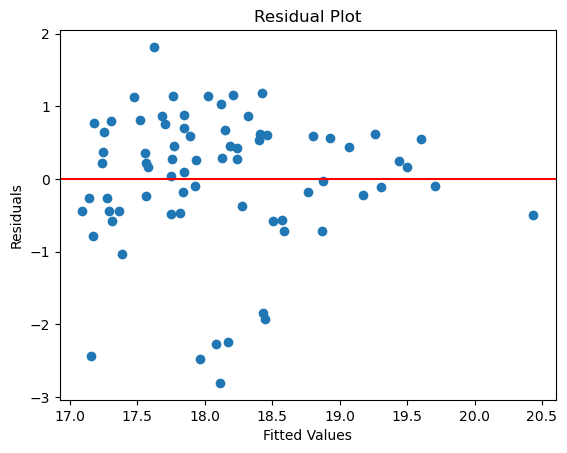

In [92]:
plt.scatter(ols_model.fittedvalues, ols_model.resid)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


🤖 🔟 Sentiment Analysis Setup

Objective:
Use a transformer model to analyze movie descriptions.
If unavailable, fallback to a keyword-based sentiment approach.

In [93]:
import re

sentiment_task = None

def keyword_sentiment_score(text):
    positive_words = {"good","great","amazing","excellent","love","awesome"}
    negative_words = {"bad","terrible","awful","worst","hate","boring"}
    tokens = re.findall(r"[a-z']+", str(text).lower())
    pos = sum(t in positive_words for t in tokens)
    neg = sum(t in negative_words for t in tokens)
    return max(-1.0, min(1.0, (pos - neg) / max(1, len(tokens))))

try:
    from transformers import pipeline
    sentiment_task = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )
except:
    pass

def calculate_sentiment(text):
    if sentiment_task is None:
        return keyword_sentiment_score(text)

    result = sentiment_task(str(text))[0]
    label = result['label'].lower()
    score = result['score']

    if 'neg' in label:
        return -score
    if 'pos' in label:
        return score
    return 0

# Faster apply
unified_view['sentiment'] = unified_view['description'].apply(calculate_sentiment)


1️⃣2️⃣ Missing Value Heatmap

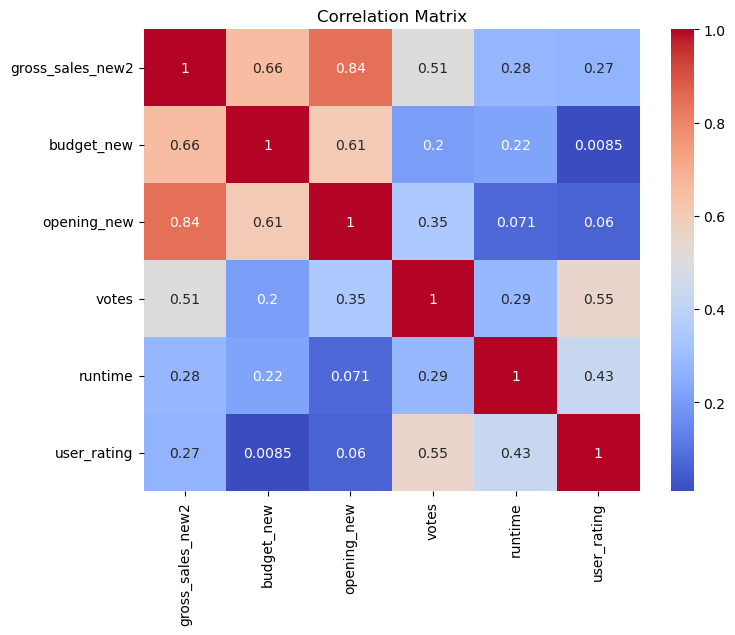

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(unified_view[numeric_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


📊 1️⃣2️⃣ Visualize Sentiment vs User Rating

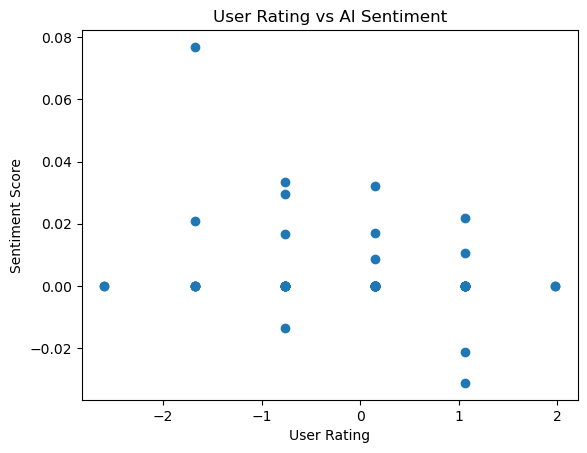

In [95]:
plt.scatter(unified_view['user_rating'], unified_view['sentiment'])
plt.title('User Rating vs AI Sentiment')
plt.xlabel('User Rating')
plt.ylabel('Sentiment Score')
plt.show()



📊 1️⃣3️⃣ User Rating Distribution

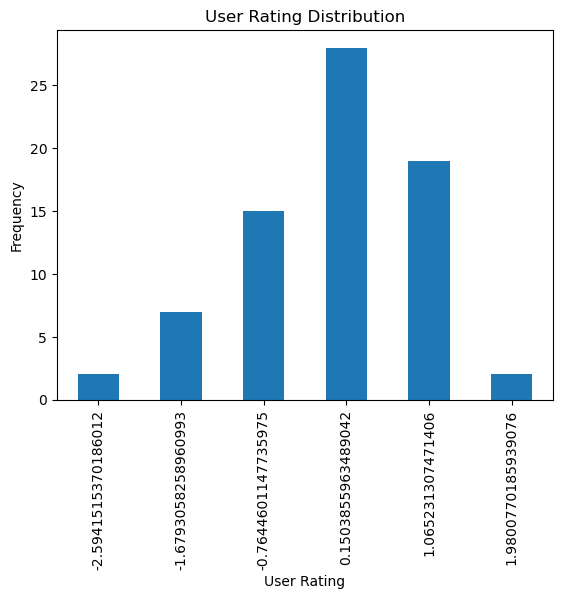

In [96]:
rating_distribution = unified_view['user_rating'].value_counts().sort_index()

rating_distribution.plot(kind='bar')
plt.title('User Rating Distribution')
plt.xlabel('User Rating')
plt.ylabel('Frequency')
plt.show()


📊 1️⃣4️⃣ Distribution of Gross Revenue (Log Scale)

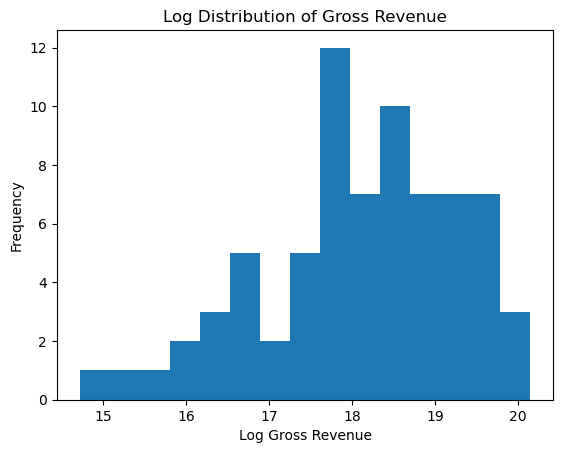

In [97]:
plt.hist(np.log1p(unified_view['gross_sales_new2']), bins=15)
plt.title('Log Distribution of Gross Revenue')
plt.xlabel('Log Gross Revenue')
plt.ylabel('Frequency')
plt.show()
